In [51]:
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing, minimize_scalar, differential_evolution

In [63]:
# Chose between rademacher or gaussian theory

#opt = 'rad'
opt = 'gauss'

In [64]:
Gamma = 0.5
gamma = 0.5

In [ ]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

_GH_ORDER = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)   # nodes & weights for e^{-x^2}
_GH_scale = 1.0 / np.sqrt(np.pi)
# transform to standard-normal nodes z = sqrt(2) * x
_GH_z = np.sqrt(2.0) * _GH_x          # shape (N,)
_GH_w_scaled = _GH_w * _GH_scale      # shape (N,)

def _gh_expectation_from_vals(vals):
    return np.tensordot(_GH_w_scaled, vals, axes=(0,0))


# Choose the readout type
# Options: 'Read_gauss', 'Read_ones', 'Read_unif', 'Read_rad', Read_4point
readouts = 'Read_4point'

if readouts == 'Read_gauss':
    data = np.loadtxt('gauss.csv', delimiter=',')
elif readouts == 'Read_rad':
    data = np.loadtxt('rad.csv', delimiter=',')
elif readouts == 'Read_ones':
    data = np.loadtxt('ones.csv', delimiter=',')
elif readouts == 'Read_unif':
    data = np.loadtxt('unif.csv', delimiter=',')
elif readouts == 'Read_4point':
    data = np.loadtxt('4point.csv', delimiter=',')

# Extract data
lambdas = data[0, :]
m_values = data[1, :]
M_values = data[2, :]

m_spline = CubicSpline(lambdas, m_values, extrapolate=True)
M_spline = CubicSpline(lambdas, M_values, extrapolate=True)


def m_05(lam, m_spline_local=None):
    spline = m_spline_local if m_spline_local is not None else globals().get('m_spline', None)
    if spline is None:
        raise NameError("m_spline not found. Create it with CSV loading or pass m_spline_local.")
    lam_arr = np.asarray(lam)
    out = spline(lam_arr)   # returns scalar or array depending on input
    if out.shape == ():
        return float(out)
    return np.asarray(out)


def iota_05(lam, M_spline_local=None):
    spline = M_spline_local if M_spline_local is not None else globals().get('M_spline', None)
    if spline is None:
        raise NameError("M_spline not found. Create it with CSV loading or pass M_spline_local.")
    lam_arr = np.asarray(lam)
    Mvals = spline(lam_arr)
    out = (lam_arr - Mvals) / 4.0
    if out.shape == ():
        return float(out)
    return np.asarray(out)


def psi_w_arr(l_arr, opt='gauss'):
    l = np.asarray(l_arr)
    if opt == 'gauss':
        return l / (1.0 + l)
    # else use GH quadrature for tanh integrals (rad or similar)
    l_flat = l.ravel()
    sqrt_l = np.sqrt(np.maximum(0.0, l_flat))  # avoid complex for negative l
    # build arguments of tanh at GH nodes: shape (N, L)
    arg = _GH_z[:, None] * sqrt_l[None, :] + l_flat[None, :]
    vals = np.tanh(arg)                         # (N, L)
    exps = _gh_expectation_from_vals(vals)     # (L,)
    return exps.reshape(l.shape)


def psi_arr_scalar(l, opt='gauss'):
    return float(psi_w_arr(np.asarray(l), opt=opt).item())


def psi_free_energy_arr(g_arr, opt='gauss'):
    g = np.asarray(g_arr)
    if opt == 'gauss':
        return 0.5 * g - 0.5 * np.log(1.0 + g)
    g_flat = g.ravel()
    sqrt_g = np.sqrt(np.maximum(0.0, g_flat))
    arg = _GH_z[:, None] * sqrt_g[None, :] + g_flat[None, :]
    vals = np.log(np.cosh(arg))
    exps = _gh_expectation_from_vals(vals)
    out = -0.5 * g_flat + exps
    return out.reshape(g.shape)

def EE_v(arr, P_v):
    P_v = np.asarray(P_v)
    return np.tensordot(P_v, arr, axes=(0,0))


def EE_v2_g(q_W, v, P_v, g):
    q_W = np.asarray(q_W)
    return np.dot(P_v, (v**2) * g(q_W))


def EE_v2_qW2(q_W, v, P_v):
    q_W = np.asarray(q_W)
    return np.dot(P_v, (v**2) * (q_W**2))


def _m_05_vec(l):

    l = np.asarray(l)
    try:
        res = m_05(l)   # m_05 may accept arrays directly (fast)
        return np.asarray(res)
    except Exception:
        vec = np.vectorize(lambda x: m_05(x))
        return np.asarray(vec(l))


def _iota_05_vec(l):

    l = np.asarray(l)
    try:
        res = iota_05(l)
        return np.asarray(res)
    except Exception:
        vec = np.vectorize(lambda x: iota_05(x))
        return np.asarray(vec(l))


def m_s_inv_05_fast(q_W, gamma, v, P_v, bracket_hi=1.0, max_hi=1e6):
    target = EE_v2_qW2(q_W, v, P_v)

    def f_scalar(l):
        val = _m_05_vec(np.array([l]))  # shape (1,)
        return float(val[0]) - float(target)

    f0 = f_scalar(0.0)
    if abs(f0) < 1e-12:
        return 0.0

    lo = 0.0
    hi = float(bracket_hi)
    fhi = f_scalar(hi)
    if f0 * fhi <= 0:
        try:
            root = brentq(f_scalar, lo, hi, xtol=1e-12, maxiter=200)
            return float(root)
        except Exception:
            pass

    # doubling
    while f0 * fhi > 0 and hi < max_hi:
        hi *= 2.0
        fhi = f_scalar(hi)

    if f0 * fhi > 0:
        # fallback: return endpoint closer to zero-residual
        if abs(f0) <= abs(fhi):
            return 0.0
        return float(hi)

    root = brentq(f_scalar, lo, hi, xtol=1e-12, maxiter=200)
    return float(root)


def derivative_mmse_05_fast(l, ratio, h=1e-6):

    l = float(l)
    m_plus = float(_m_05_vec(np.array([l + h]))[0])
    m_minus = float(_m_05_vec(np.array([l - h]))[0])
    # derivative of mmse = ( (1 - m_plus) - (1 - m_minus) ) / (2h)
    return ( (1.0 - m_plus) - (1.0 - m_minus) ) / (2.0 * h)


In [ ]:
def Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                           max_iter=100, tol=1e-6):
    mu1_sq = coeff[1]**2
    mu2_sq = coeff[2]**2

    r_K = coeff[1]**2 + rho_2 * coeff[2]**2 / 2.0 + g(1.0)

    # initialize q_K_new
    q_K_new = r_K / 2.0

    for _ in range(max_iter):
        q_K_old = q_K_new
        # r_2 scalar
        r_2 = alpha * (1.0 / (delta + r_K - q_K_old)) * (coeff[2]**2)
        # find \tilde{q} solving m_05(\tilde{q}) = E_v[ v^2 q_W^2 ]
        tilde_q = m_s_inv_05_fast(q_W, gamma, v, P_v)
        # q_2 = m_05(tilde_q + r_2) + (rho_2 - 1)  (scalar)
        q_2 = float(_m_05_vec(np.array([tilde_q + r_2]))[0]) + (rho_2 - 1.0)
        # update q_K
        q_K_new = coeff[1]**2 + (coeff[2]**2) / 2.0 * q_2 + EE_v2_g(q_W, v, P_v, g)
        if abs(q_K_new - q_K_old) < tol:
            break

    return r_K, q_K_new


def mmse_qW_q2_full_NSB_iter_05_fast(q_W_init, v, P_v, g, g_prime,
                                     coeff, alpha, gamma, delta, rho_2,
                                     max_iter=1000, tol=1e-6, dump=0.2, univ=False):
    q_W = np.array(q_W_init, dtype=float).copy()  # shape (V,)
    V = v.shape[0]

    r_W = np.empty_like(q_W)

    r_K, q_K = Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                                         max_iter=200, tol=1e-6)

    for it in range(max_iter):
        # compute r_K and q_K using Kappa_full_NSB_05_fast
        # scalar r_2 and q_2
        r_2 = alpha * (1.0 / (delta + r_K - q_K)) * (coeff[2]**2)
        # compute tilde_q scalar
        tilde_q = m_s_inv_05_fast(q_W, gamma, v, P_v)
        # q_2 scalar
        q_2 = float(_m_05_vec(np.array([tilde_q + r_2]))[0]) + (rho_2 - 1.0)

        E_v2_qW2_val = EE_v2_qW2(q_W, v, P_v)  # scalar
        denom_common = 1.0 + r_2 * (1.0 - E_v2_qW2_val)  # scalar
        # derivative of mmse at tilde_q: d_mmse/dl evaluated at l=tilde_q
        d_mmse = derivative_mmse_05_fast(tilde_q, gamma, h=1e-6)  # scalar
        if abs(d_mmse) < 1e-12:
            d_mmse = np.sign(d_mmse) * 1e-12 if d_mmse != 0 else 1e-12

        # Vectorized computation of r_W for all v:
        # r_W[v] = (1/(2*gamma)) * (q_2 - (rho_2-1) - E_v2_qW2) * ( -2 * v[v]^2 * q_W[v] / derivative_mmse(tilde_q) )
        #          + (alpha/gamma) * v[v]^2 * g_prime(q_W[v]) / (delta + r_K - q_K)
        scalar_pref = (1.0 / (2.0 * gamma)) * (q_2 - (rho_2 - 1.0) - E_v2_qW2_val)
        # first term vector: -2 * v^2 * q_W / d_mmse
        term1 = scalar_pref * ( -2.0 * (v**2) * q_W / d_mmse )
        term2 = (alpha / gamma) * (v**2) * g_prime(q_W) / (delta + r_K - q_K)
        r_W[:] = term1 + term2

        try:
            psi_opt = globals().get('opt', 'gauss')
        except Exception:
            psi_opt = 'gauss'
        q_W_new = psi_w_arr(r_W, opt=psi_opt)

        q_W = dump * q_W_new + (1.0 - dump) * q_W

        if univ:
            # enforce universal solution q_W[v] = 0
            q_W = np.zeros_like(q_W)

        r_K_new, q_K_new = Kappa_full_NSB_05_fast(q_W, v, P_v, g, coeff, alpha, gamma, delta, rho_2,
                                         max_iter=200, tol=1e-6)

        # convergence check (sup norm)
        if (np.abs(q_K_new - q_K) < tol):
            break

        q_K = q_K_new
        r_K = r_K_new

    mmse = r_K_new - q_K_new
    return mmse, q_W, q_2


In [ ]:
def hermite_coefficients(func, n, a, b):
    # Define the Hermite polynomials
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients
    coefficients = []
    for i in range(n+1):
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    # Create a grid of states between -mult_sigma*sigma and mult_sigma*sigma
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    # Compute unnormalized probabilities using the Gaussian pdf with mean mu and variance sigma^2
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    # Normalize the weights to get probabilities
    P_v = weights / np.sum(weights)
    return v, P_v    


C:\Users\rudys\AppData\Local\Temp\ipykernel_14144\4230278687.py:33: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)


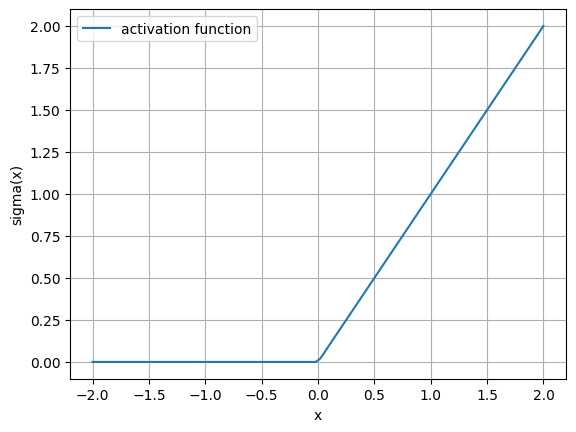

[ 3.98942280e-01  5.00000000e-01  3.98942280e-01  0.00000000e+00
 -3.98942280e-01  0.00000000e+00  1.19682684e+00 -3.06519084e-15
 -5.98413421e+00 -4.62916347e-14  4.18889394e+01 -4.68958206e-12
 -3.77000455e+02 -3.70619091e-10  4.14700500e+03 -2.71079443e-08
 -5.39110651e+04 -1.85886165e-06  8.08665976e+05 -1.18081458e-04
 -1.37473216e+07 -6.87409192e-03  2.61199110e+08 -3.60938191e-01]


In [70]:
# choose the activation function among the activations below
# the cell computes the first num_coeff Hermite coefficients and defines the function g()

activation = 'ReLU' # 'ReLU', 'Tanh', 'Softplus', 'Erf', 'Arctan', 'LeakyReLU', 'ELU', 'Sigmoid', 'Quadratic', 'Cubic', 'Quadratic + Cubic', 'Linear + Quadratic + Cubic', 'Quadratic + Quartic'
num_coeff = 23

if (activation == 'ReLU'):
  analytic = True
else:
  analytic = False


if (analytic == True):
 if (activation == 'ReLU'):

      def sigma(x):
        return np.heaviside(x,1)*x

      def g(x):
        return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)

      def g_prime(x):
        return (np.arctan(x/np.sqrt(1-x**2))-x)/(2*np.pi)

      coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

else:

  if (activation == 'Tanh'):
    def sigma(x):
        return np.tanh(2*x)

  elif (activation == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma(x):
        return np.tanh(2*x)/np.sqrt(var)       

  elif (activation == 'ReLU numeric'):
    def sigma(x):
        return np.heaviside(x,1)*x

  elif (activation == 'Softplus'):
    def sigma(x):
        return np.log(1+np.exp(x))  

  elif (activation == 'Erf'):
    def sigma(x):
        return 0.5*(1 + special.erf(x/np.sqrt(2)))

  elif (activation == 'Arctan'):
    def sigma(x):
        return np.arctan(x)

  elif (activation == 'LeakyReLU'):
    def sigma(x):
        return np.heaviside(x,1)*x + 0.3*np.heaviside(-x,-1)*x

  elif (activation == 'ELU'):
    def sigma(x):
        return np.heaviside(x,1)*x + np.heaviside(-x,1)*(np.exp(x) - 1)

  elif (activation == 'Sigmoid'):
    def sigma(x):
        return 1/(1+np.exp(-x))

  elif (activation == 'Quadratic'):
    def sigma(x):
        return np.power(x,2)/np.sqrt(2)

  elif (activation == 'Cubic'):
    def sigma(x):
        return (x**3 - 3*x)/np.sqrt(6)

  elif (activation == 'Quadratic + Cubic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Linear + Quadratic + Cubic'):
    def sigma(x):
        return x + (x**2 - 1)/np.sqrt(2) + (x**3 - 3*x)/6

  elif (activation == 'Quadratic + Quartic'):
    def sigma(x):
        return (x**2 - 1)/np.sqrt(2) + (x**4 - 6*x**2 + 3)/8

  coefficients = hermite_coefficients(lambda x: sigma(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
  def g(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**i / math.factorial(i)
    return g

  def g_prime(x):
    g = 0
    for i in range(3,len(coefficients)):
      g += coefficients[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma(x), label='activation function')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients)

In [71]:
num_v = 600  # Number of states
mult_sigma = 4.0  # Number of sigmas to consider
#v_ones, P_v_ones = get_states_and_probs(num_v)
#v_ones = [-1,1] 
#P_v_ones = [1/2,1/2]
#v_gauss = [1] 
#P_v_gauss = [1]
#v_ones, P_v_ones = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#v_gauss, P_v_gauss = get_discrete_gaussian_on_grid_2(num_v,0,1,mult_sigma)
#v_ones = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
#P_v_ones = [1/4,1/4,1/4,1/4]
v_gauss = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
P_v_gauss = [1/4,1/4,1/4,1/4]
v_ones = np.array(v_ones)
P_v_ones = np.array(P_v_ones)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W
q_W_init_unfo = 0*np.ones(v_gauss.shape[0]) # initial guess for q_W


# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha

Gamma = 0.5
Delta = 0.1
Alph = 3.0

if (readouts == 'Read_ones'):
  rho_2 = 1+Gamma
else:
  rho_2 = 1 

print('gen err spec =',mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v_gauss,P_v_gauss,g,g_prime,coefficients,Alph,Gamma,Delta,rho_2)[0])
print('gen err univ =',mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_unfo,v_gauss,P_v_gauss,g,g_prime,coefficients,Alph,Gamma,Delta,rho_2, univ=True)[0])
#print('K =',coefficients[1]**2 + coefficients[2]**2/2 + g(1) - mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v_gauss,P_v_gauss,g,g_prime,coefficients,3.0,Gamma,Delta,rho_2)[0])
#print('K_d =',coefficients[1]**2 + coefficients[2]**2/2 + g(1))

gen err spec = 0.015033347161089228
gen err univ = 0.0225708674009254


C:\Users\rudys\AppData\Local\Temp\ipykernel_14144\1690343770.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  return -1/(2*np.pi) - x**2/(4*np.pi) + np.sqrt(1-x**2)/(2*np.pi) + x*np.arctan(x/np.sqrt(1-x**2))/(2*np.pi)


In [ ]:
num_v = 600  # Number of states
mult_sigma = 4.0  # Number of sigmas to consider
#v_ones, P_v_ones = get_states_and_probs(num_v)
#v_ones = [-1,1] 
#P_v_ones = [1/2,1/2]
#v_gauss = [1] 
#P_v_gauss = [1]
#v_ones, P_v_ones = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
v_gauss, P_v_gauss = get_discrete_gaussian_on_grid(num_v,0,1,mult_sigma)
#v_ones = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
#P_v_ones = [1/4,1/4,1/4,1/4]
#v_gauss = [-3/np.sqrt(5),-1/np.sqrt(5),1/np.sqrt(5),3/np.sqrt(5)]
#P_v_gauss = [1/4,1/4,1/4,1/4]
v_ones = np.array(v_ones)
P_v_ones = np.array(P_v_ones)
v_gauss = np.array(v_gauss)
P_v_gauss = np.array(P_v_gauss)
q_W_init_info = 0.99*np.ones(v_gauss.shape[0]) # initial guess for q_W
q_W_init_ones = 0.99*np.ones(v_ones.shape[0]) # initial guess for q_W


# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha

Gamma = 0.5
Delta = 0.03

if (readouts == 'Read_ones'):
  rho_2 = 1+Gamma
else:
  rho_2 = 1 

# Range of alpha
Alpha_min = 0.01
Alpha_max = 10.0

init = Alpha_min
end = Alpha_max
num = 201

MMSE_NSB = []
q_W_NSB = []
q_2_NSB = []

MMSE_univ = []
q_W_univ = []
q_2_univ = []

for Alpha in np.linspace(init, end, num=num):
  if (Alpha == 0):
    Alpha = 0.01
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)

  MMSE_new,q_W_new_gauss,q_2_new=mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v_gauss,P_v_gauss,g,g_prime,coefficients,Alpha,Gamma,Delta,rho_2)
  MMSE_NSB.append(MMSE_new)
  q_W_NSB.append(q_W_new_gauss)
  q_2_NSB.append(q_2_new)
  print('MMSE NSB =',MMSE_new)
  MMSE_new,q_W_new_gauss,q_2_new=mmse_qW_q2_full_NSB_iter_05_fast(q_W_init_info,v_gauss,P_v_gauss,g,g_prime,coefficients,Alpha,Gamma,Delta,rho_2, univ=True)
  MMSE_univ.append(MMSE_new)
  q_W_univ.append(q_W_new_gauss)
  q_2_univ.append(q_2_new)
  print('MMSE univ =',MMSE_new)

gen err spec = 0.00013446158166718902
gen err univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.01
MMSE NSB = 0.10267295078048133
MMSE univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.05995
MMSE NSB = 0.10266853903013806
MMSE univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.1099
MMSE NSB = 0.10213799155535774
MMSE univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.15985000000000002
MMSE NSB = 0.09971779508267753
MMSE univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.20980000000000001
MMSE NSB = 0.09515478275717337
MMSE univ = 0.10267380199215137
----------------------------------------------------------------
alpha = 0.25975
MMSE NSB = 0.08897251093275993
MMSE univ = 0.10267380199215137
-------------------------------------------

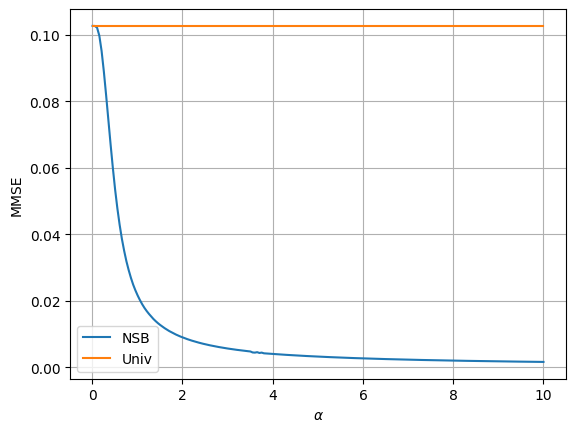

In [ ]:
plt.plot(np.linspace(init, end, num=num),MMSE_NSB, label='NSB')
plt.plot(np.linspace(init, end, num=num),MMSE_univ, label='Univ')


#plt.title('MMSE with '+activation+' activation and delta ='+str(Delta)+' and gamma = '+str(Gamma))
plt.xlabel(r'$\alpha$')
plt.ylabel('MMSE')
plt.legend()
plt.grid(True)

plt.show()